<a href="https://colab.research.google.com/github/seanperdomo/Proyecto_2_MD/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Disección de un Campo Profundo Multi-Longitud de Onda** - Proyecto 2 - Minería de Datos
### **Estudiantes:**

*   Soleil Dayana Niño Murcia
*   Sean Paul Perdomo

### **Problema Astrofísico:**

Los astrónomos modernos no observan un solo objeto; apuntan sus telescopios a un “Campo Profundo” (un parche de cielo) y extraen todo lo que hay en él utilizando diferentes longitudes de onda.

Su misión como equipo es analizar el campo ecuatorial centrado en las coordenadas RA: 135.5, Dec: 0.5 (con un radio de 0.5 grados). Deben cartografiar esta región para separar las estrellas locales de nuestra galaxia, aislar las galaxias lejanas y descubrir cuásares enrojecidos por el polvo. Para lograrlo, deberán combinar astrometría, espectroscopía y fotometría óptica e infrarroja.

## Configuración Python

Librerias:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Misión A: El Cartógrafo Galáctico (VizieR)**

* **GitHub:** Crea una rama (branch) en el repositorio llamada pipeline_vizier.

* **Extracción:** Utiliza una celda de comandos de Bash en Colab para enviar una consulta ADQL al endpoint de VizieR.

* **Lógica de Datos:** Debes realizar un cruce espacial masivo (un LEFT JOIN con un radio de 2 arcosegundos) entre la base de datos de Gaia DR3 (astrometría óptica) y AllWISE (fotometría infrarroja). Extrae el paralaje, los movimientos propios y las magnitudes principales (Gmag, W1mag) de todos los objetos en el campo profundo especificado.

* **Análisis:** En Python, limpia los datos. Utiliza el Paralaje para aislar únicamente las estrellas que pertenecen a nuestra galaxia. Grafica un Diagrama Color-Magnitud Óptico-Infrarrojo (ej. $G - W_1$ vs. $G$) para tu población estelar. Sube tus cambios a GitHub y crea un Pull Request.

## Query y descarga de datos

In [3]:
%%bash

QUERY="SELECT+TOP+5000+g.Gmag,g.Plx,g.PMRA,g.PMDE,w.W1mag+FROM+\"I/355/gaiadr3\"+AS+g+INNER+JOIN+\"II/328/allwise\"+AS+w+ON+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',g.RA_ICRS,g.DE_ICRS, 0.00056))+WHERE+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',135.5,0.5,0.5))+AND+1=CONTAINS(POINT('ICRS',g.RA_ICRS,g.DE_ICRS),CIRCLE('ICRS',135.5,0.5,0.5))"
TAP="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query="
URL="${TAP}${QUERY}"
URL_CLEAN=$(echo $URL | sed 's\ \+\g')

wget -q -O mag_y_par.csv "$URL_CLEAN"


## Configuración Python

Librerias:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dataframe limpio:

In [5]:
df = pd.read_csv("mag_y_par.csv").dropna()

In [6]:
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3789,18.231508,-0.0996,-1.470,0.442,16.806
3790,19.139265,0.6747,-10.229,5.447,15.698


Se considera 15kpc como el radio galáctico, lo que es equivalente a un paralaje 1/15 milisegundos de arco. El paralaje proporcionado por Vizier está en milisegundos de arco, por lo que no es necesario realizar la conversión.

In [7]:
df = df[df['Plx'] > 1/15] # Estrellas dentro de la galaxia
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3790,19.139265,0.6747,-10.229,5.447,15.698


Se calcula el índice de color:

In [8]:
df['G-W'] = df['Gmag'] - df['W1mag']
df

/tmp/ipykernel_4655/339990965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['G-W'] = df['Gmag'] - df['W1mag']


,Gmag,Plx,pmRA,pmDE,W1mag,G-W
0,20.026037,5.6234,-4.673,-4.926,15.817,4.209037
1,15.976371,6.3935,37.901,-70.548,12.282,3.694371
2,16.363176,0.7983,0.717,-2.661,14.528,1.835176
3,16.236700,0.4631,-5.962,-2.177,14.872,1.364700
4,18.048435,0.3126,-3.634,2.585,16.118,1.930435
...,...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146,1.275206
3787,16.182987,1.2489,-11.382,5.447,13.635,2.547987
3788,16.697906,0.3429,-1.637,-0.220,15.266,1.431906
3790,19.139265,0.6747,-10.229,5.447,15.698,3.441265


Se grafica el diagrama color-magnitud:

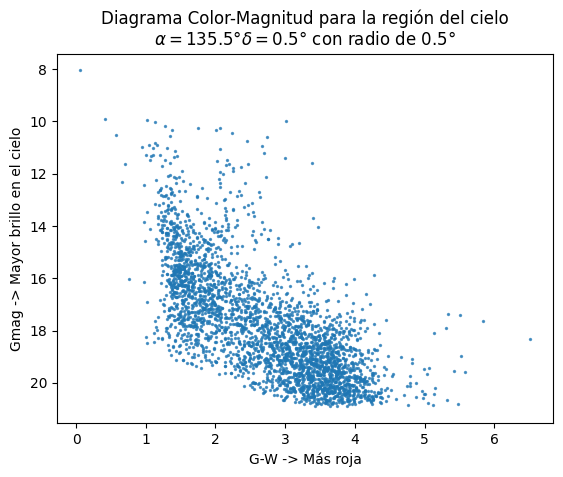

In [9]:
plt.scatter(df['G-W'], df['Gmag'], s=2, alpha=0.7)
plt.title('Diagrama Color-Magnitud para la región del cielo\n'+ r'$\alpha=135.5$°$\delta=0.5$° con radio de 0.5°')
plt.ylabel('Gmag -> Mayor brillo en el cielo')
plt.xlabel('G-W -> Más roja')
plt.gca().invert_yaxis()
plt.savefig('cmd_1.png')
plt.show()

# Misión B: El Cosmólogo (SDSS & MAST)

## Extracción: Celda de Bash para enviar una consulta SQL al SkyServer de SDSS.



Query:

```
SELECT
    s.specObjID,
    s.class,
    s.z,
    p.objID,
    p.ra,
    p.dec,
    p.u,
    p.g
FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n
JOIN PhotoObj AS p ON p.objID = n.objID
JOIN SpecObj  AS s ON s.bestObjID = p.objID
WHERE p.u > -9999 AND p.g > -9999
```

Notas:
* En SDSS SkyServer no se pone el cono como un WHERE ra BETWEEN manualmente, sino con la función dbo.fGetNearbyObjEq(ra, dec, radio_en_arcmin)

* El radio en esta función va en arcominutos, así que se aplica 0.5° = 30 arcmin.
* Se descartan valores erráticos de -9999

In [10]:
%%bash
curl -s -G "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch" \
  --data-urlencode "format=csv" \
  --data-urlencode "cmd=SELECT s.specObjID, s.class, s.z, p.objID, p.ra, p.dec, p.u, p.g
FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n
JOIN PhotoObj AS p ON p.objID = n.objID
JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE p.u > -9999 AND p.g > -9999" \
  -o sdss_campo_profundo.csv

head -5 sdss_campo_profundo.csv

#Table1
specObjID,class,z,objID,ra,dec,u,g
4298836020475222016,STAR,0.001112651,1237648722284970282,135.467286599139,0.744141243175628,19.48259,18.58256
4298836845108942848,GALAXY,0.5428114,1237648722284970681,135.452326422006,0.79870532731921,22.26601,21.83075
528067154491238400,GALAXY,0.1993671,1237648722285035895,135.544900495677,0.801934442380106,19.8855,18.57996


In [11]:
data_B = pd.read_csv("sdss_campo_profundo.csv", comment='#')
data_B

,specObjID,class,z,objID,ra,dec,u,g
0,4298836020475222016,STAR,0.001113,1237648722284970282,135.467287,0.744141,19.48259,18.58256
1,4298836845108942848,GALAXY,0.542811,1237648722284970681,135.452326,0.798705,22.26601,21.83075
2,528067154491238400,GALAXY,0.199367,1237648722285035895,135.544900,0.801934,19.88550,18.57996
3,14111163167041411072,GALAXY,0.017546,1237674460949840573,135.410753,0.064547,23.77866,23.22599
4,528078424485423104,GALAXY,0.052833,1237674461486842216,135.423503,0.582765,18.00536,16.63779
...,...,...,...,...,...,...,...,...
247,4296448976369244160,GALAXY,0.000203,1237648722284970789,135.505717,0.662653,23.40528,21.36610
248,4298871204847310848,GALAXY,0.296462,1237650796752405286,135.984392,0.588548,23.33717,20.66373
249,529238959276976128,GALAXY,0.409645,1237674460949905870,135.576781,0.035211,24.92165,20.95431
250,4296457222706452480,GALAXY,0.000240,1237674461486842703,135.439565,0.574691,22.88839,21.96896


Graficar redshift vs. índice de color (u-g)

In [12]:
# Crear columna de índice de color u - g
data_B['u-g'] = data_B['u'] - data_B['g']
data_B

,specObjID,class,z,objID,ra,dec,u,g,u-g
0,4298836020475222016,STAR,0.001113,1237648722284970282,135.467287,0.744141,19.48259,18.58256,0.90003
1,4298836845108942848,GALAXY,0.542811,1237648722284970681,135.452326,0.798705,22.26601,21.83075,0.43526
2,528067154491238400,GALAXY,0.199367,1237648722285035895,135.544900,0.801934,19.88550,18.57996,1.30554
3,14111163167041411072,GALAXY,0.017546,1237674460949840573,135.410753,0.064547,23.77866,23.22599,0.55267
4,528078424485423104,GALAXY,0.052833,1237674461486842216,135.423503,0.582765,18.00536,16.63779,1.36757
...,...,...,...,...,...,...,...,...,...
247,4296448976369244160,GALAXY,0.000203,1237648722284970789,135.505717,0.662653,23.40528,21.36610,2.03918
248,4298871204847310848,GALAXY,0.296462,1237650796752405286,135.984392,0.588548,23.33717,20.66373,2.67344
249,529238959276976128,GALAXY,0.409645,1237674460949905870,135.576781,0.035211,24.92165,20.95431,3.96734
250,4296457222706452480,GALAXY,0.000240,1237674461486842703,135.439565,0.574691,22.88839,21.96896,0.91943


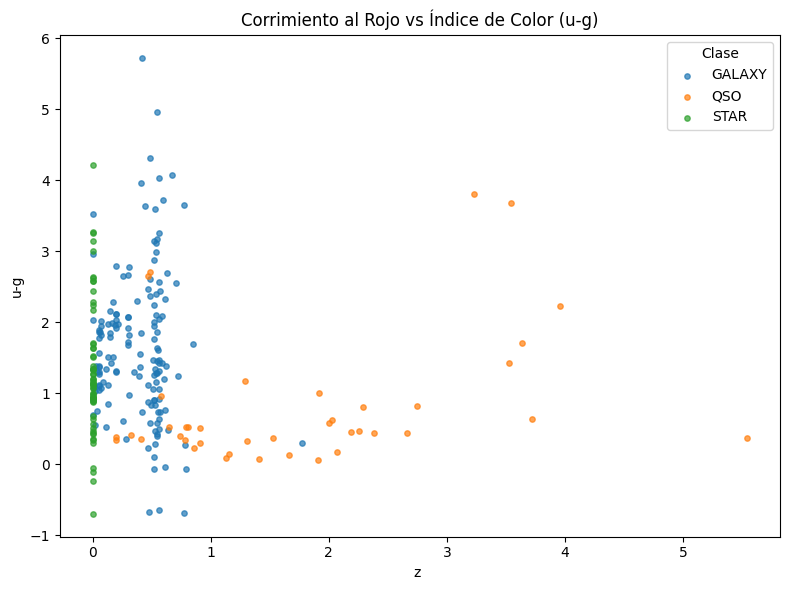

In [13]:
# Graficar agrupando por clase de objeto
plt.figure(figsize=(8, 6))

# Agrupar y graficar cada clase con un color diferente
for name, group in data_B.groupby('class'):
    plt.scatter(group['z'], group['u-g'], s=15, alpha=0.7, label=name)

plt.ylabel('u-g')
plt.xlabel('z ')
plt.title('Corrimiento al Rojo vs Índice de Color (u-g)')
plt.legend(title='Clase')
plt.tight_layout()
plt.savefig('cmd_2.png')
plt.show()